# Background

Rumah salah satu kebutuhan dasar manusia sekaligus aset investasi yang nilainya terus berkembang. Faktanya, harga rumah itu bervariasi. Sebagian rumah berada di bawah rata-rata pasar, sebagian lainnya melampaui rata-rata, dan tidak jarang dijumpai properti dengan harga yang tidak lazim. Penelitian ini bertujuan untuk mengidentifikasi dan menganalisis variabel-variabel yang secara signifikan membedakan rumah dengan harga di bawah rata-rata, di atas rata-rata, serta rumah yang tergolong anomali dalam dataset.

# Problem Statement

- Apa yang membedakan harga rumah dibawah/diatas rata rata


# Data Spesification

In [8]:
# Import Library
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind, mannwhitneyu, shapiro

In [2]:
df = pd.read_csv('./Housing.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [17]:
# Drop kolom stories karena tidak impactful (hanya menyatakan jumlah stories, bukan tentang apa) 
df = df.drop('stories', axis=1)

In [4]:
df.shape

(545, 13)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [18]:
len(df[df.duplicated()])

0

In [11]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


- Dimensi data terdiri dari 545 row dan 13 kolom (6 Numerical dan 7 Categorical)
- Tidak ada null value
- Tidak ada duplikat
- Jika dilihat pada summary statistik, diduga kolom price, area, bathrooms, stories, and parking memiliki distribusi yang tidak normal. Dikarenakan mean dan median punya selisih.
- Kolom bedroom mendekati distribusi normal

# Data Transform

In [ ]:
# Buat kolom baru bernama 'status' untuk mengkategorisasi rumah:
# - yang diatas rata rata, 
# - dibawah rata rata, 
# - dan outlier
iqr = df['price'].quantile(0.75) - df['price'].quantile(0.25)

def get_status(price):
    if price > df['price'].quantile(0.75) + 1.5 * iqr:
        return 'outliers'
    elif price > df['price'].mean():
        return 'above_avg'
    elif price <= df['price'].mean():
        return 'below_avg'
    
    
df['status'] = df['price'].apply(get_status)
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,status
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished,outliers
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished,outliers
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished,outliers
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished,outliers
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished,outliers


# Exploratory Data Analysis

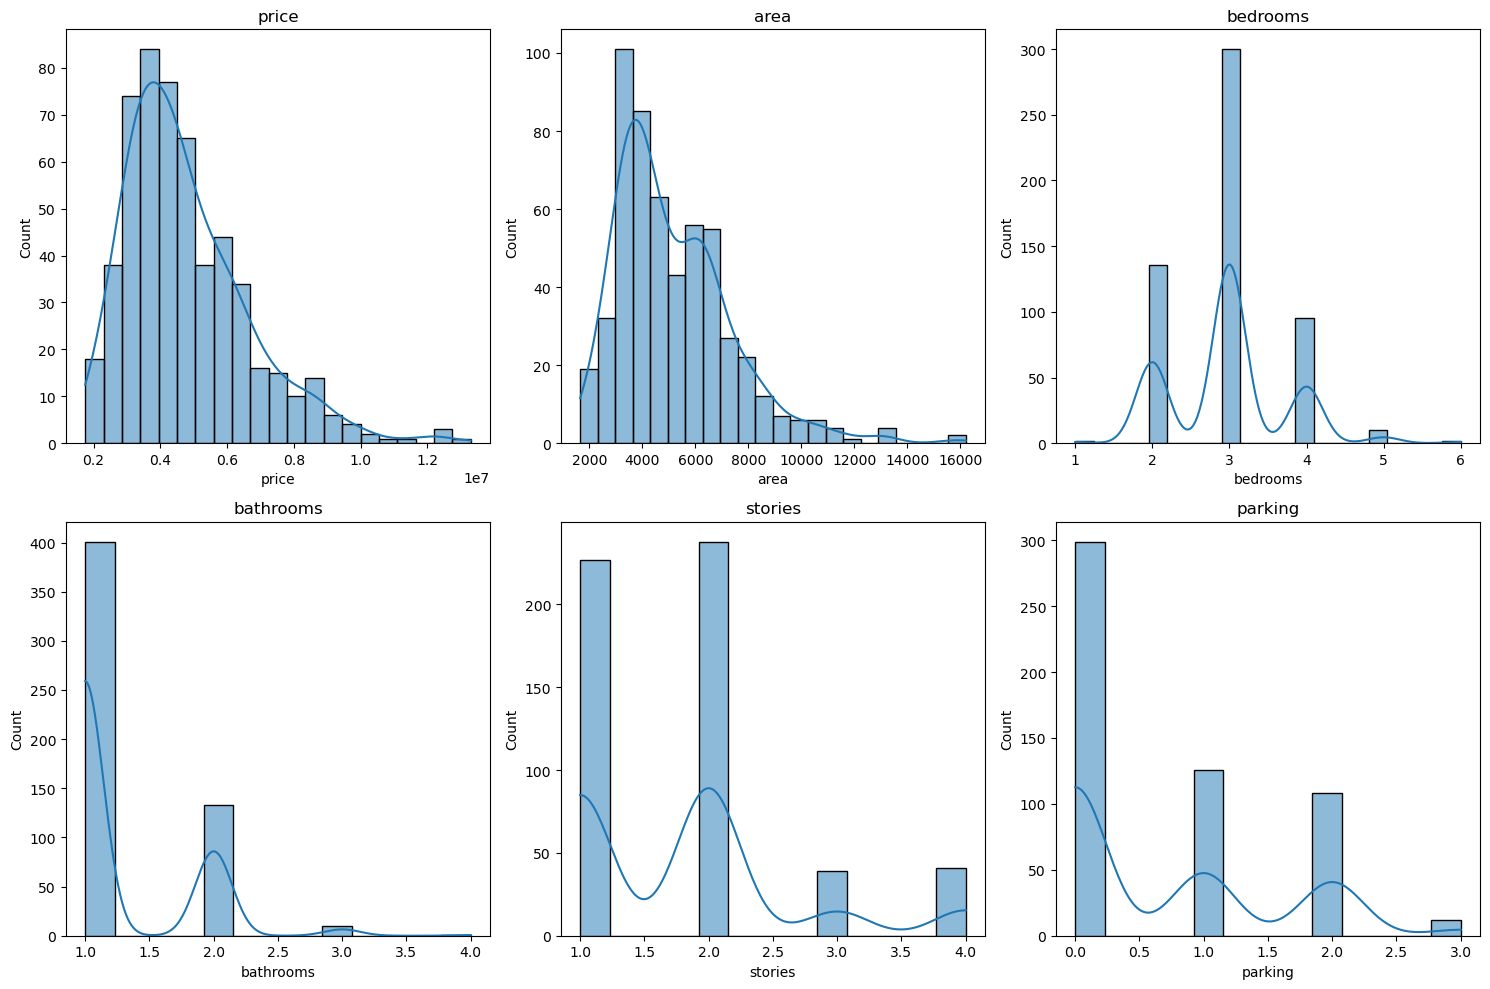

<Figure size 640x480 with 0 Axes>

In [107]:
num_cols = df.select_dtypes(include='number').columns
n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)
    

plt.tight_layout()
plt.show()
plt.tight_layout()


- Kolom price, area, bathrooms, stories, and parking memiliki distribusi right skewness

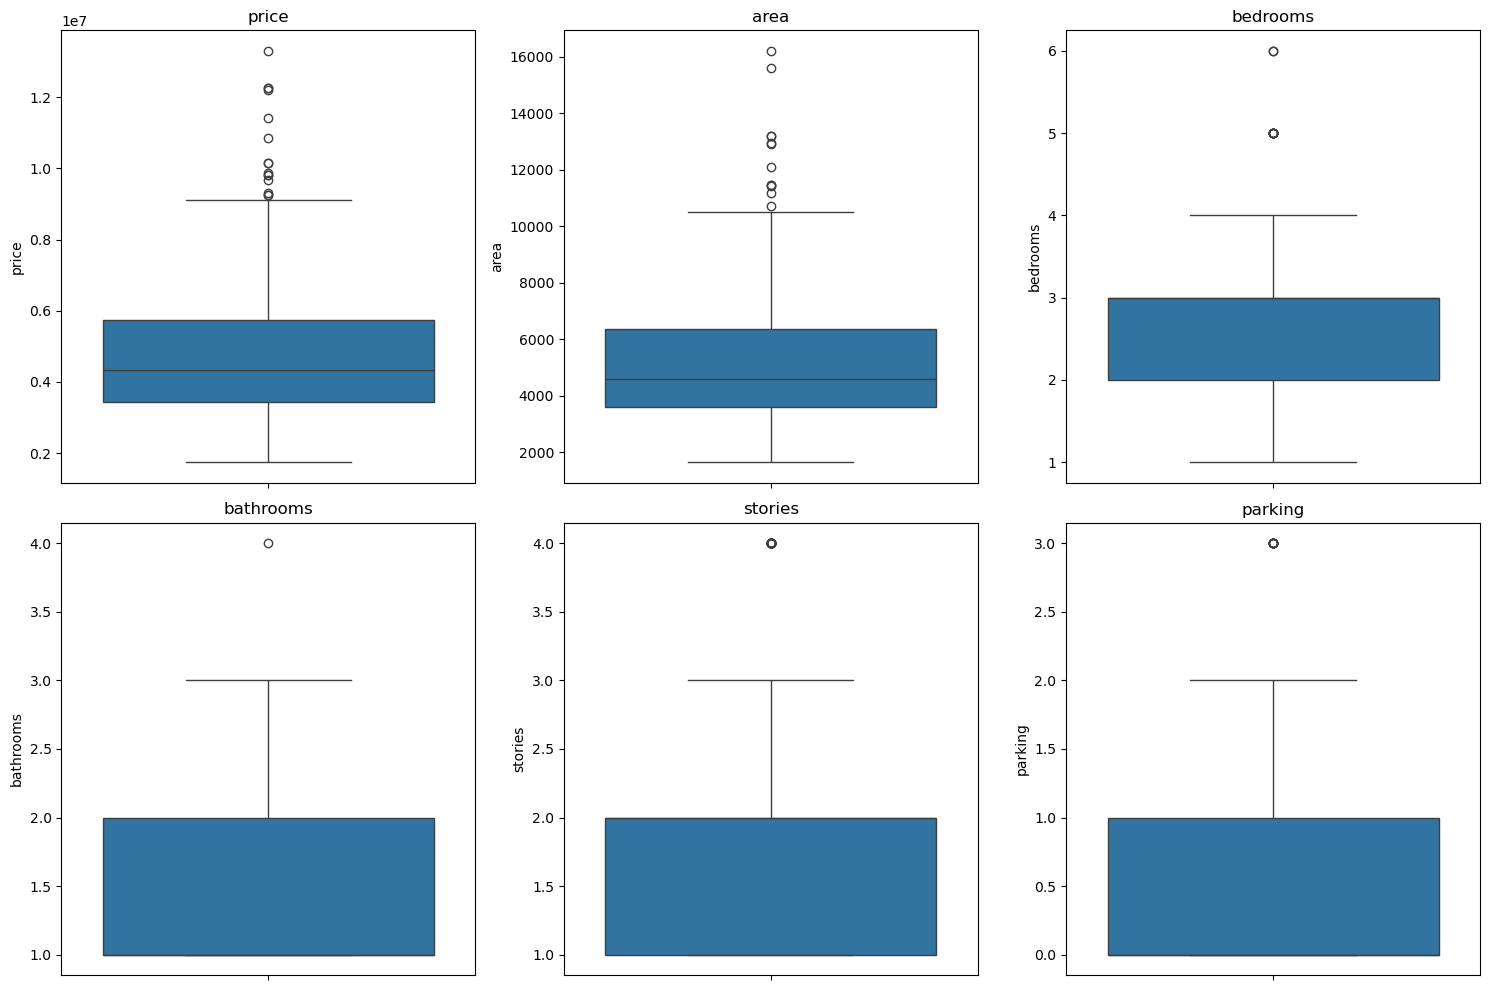

In [100]:
num_cols = df.select_dtypes(include='number').columns

n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

# hapus subplot kosong
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

- Semua data numerical memiliki outliers

<Axes: xlabel='status', ylabel='bedrooms'>

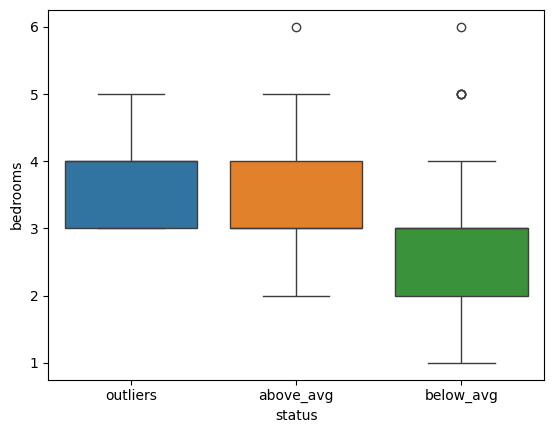

In [133]:
sns.boxplot(y=df['bedrooms'],x=df['status'], hue=df['status'])

Below Average:
- Ada rumah yang memiliki satu kamar tidur 

Above Average:
- Minimum kamar tidur yang dimiliki oleh rumah yang diatas rata rata adalah sejumlah 2 kamar tidur

Outliers:
- Rumah pada kelompk harga outlier, sudah pasti memiliki lebih dari 2 kamar tidur

<Axes: xlabel='status', ylabel='bathrooms'>

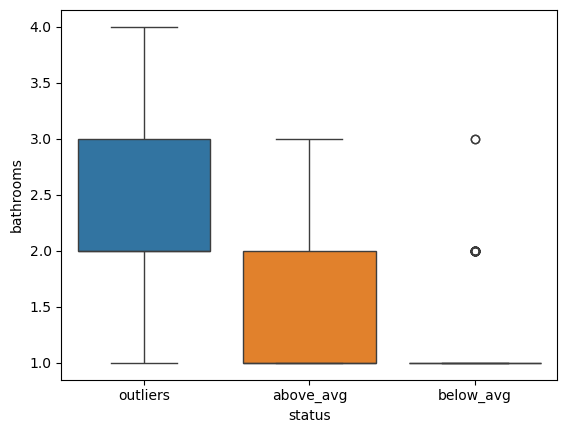

In [134]:
sns.boxplot(y=df['bathrooms'],x=df['status'], hue=df['status'])

- Rumah dengan kategori harga outlier dapat memiliki jumlah kamar mandi sebanyak 4. dimana nilai paling tinggi diantara above average dan below average.
- Selain itu, mayoritas below average hanya memiliki 1 kamar mandi

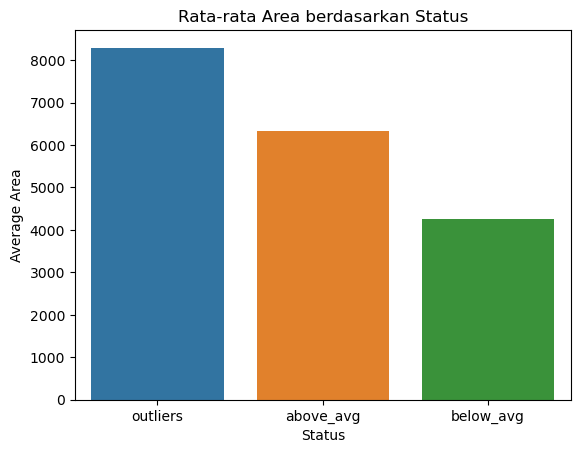

In [125]:
avg_area = df.groupby('status')['area'].mean().reset_index().sort_values('area', ascending=False)
sns.barplot(x='status', y='area', data=avg_area, hue='status')

plt.title('Rata-rata Area berdasarkan Status')
plt.xlabel('Status')
plt.ylabel('Average Area')
plt.show()

- Outliers memiliki rata rata luas area rumah paling tinggi, lalu diikuti oleh above avarage dan below average

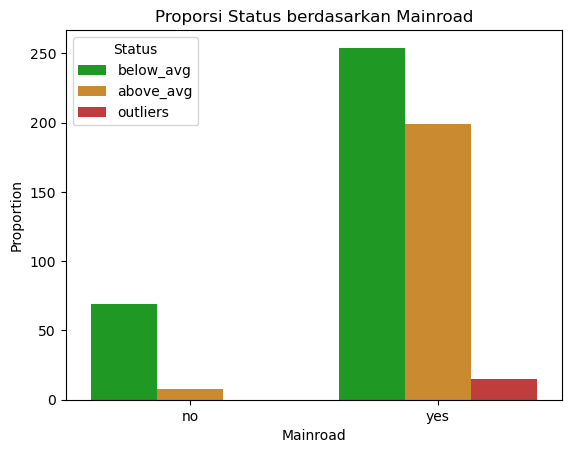

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

ct = pd.crosstab(df['mainroad'], df['status'])
ct_long = ct.reset_index().melt(id_vars='mainroad', 
                               var_name='status', 
                               value_name='proportion')
sns.barplot(data=ct_long, 
            x='mainroad', 
            y='proportion', 
            hue='status',
            hue_order=['below_avg', 'above_avg', 'outliers'],
            palette=["#0bac11", "#e48e15", '#d62728'])

plt.title('Proporsi Status berdasarkan Mainroad')
plt.ylabel('Proportion')
plt.xlabel('Mainroad')
plt.legend(title='Status')
plt.show()

Rumah dengan kategori harga outlier selalu terhubung oleh jalan protokol/mainroad

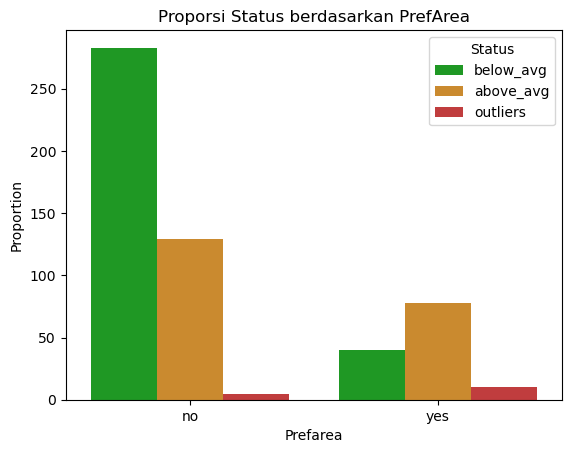

In [21]:
import pandas as pd

ct = pd.crosstab(df['prefarea'], df['status'])
ct_long = ct.reset_index().melt(id_vars='prefarea', 
                               var_name='status', 
                               value_name='proportion')
sns.barplot(data=ct_long, 
            x='prefarea', 
            y='proportion', 
            hue='status',
            hue_order=['below_avg', 'above_avg', 'outliers'],
            palette=["#0bac11", "#e48e15", '#d62728'])

plt.title('Proporsi Status berdasarkan PrefArea')
plt.ylabel('Proportion')
plt.xlabel('Prefarea')
plt.legend(title='Status')
plt.show()

- Distribusi rumah mayoritas bukan di preffered area
- Pada rumah yang berlokasi di prefered area, di dominasi oleh rumah dengan kategori harga above average

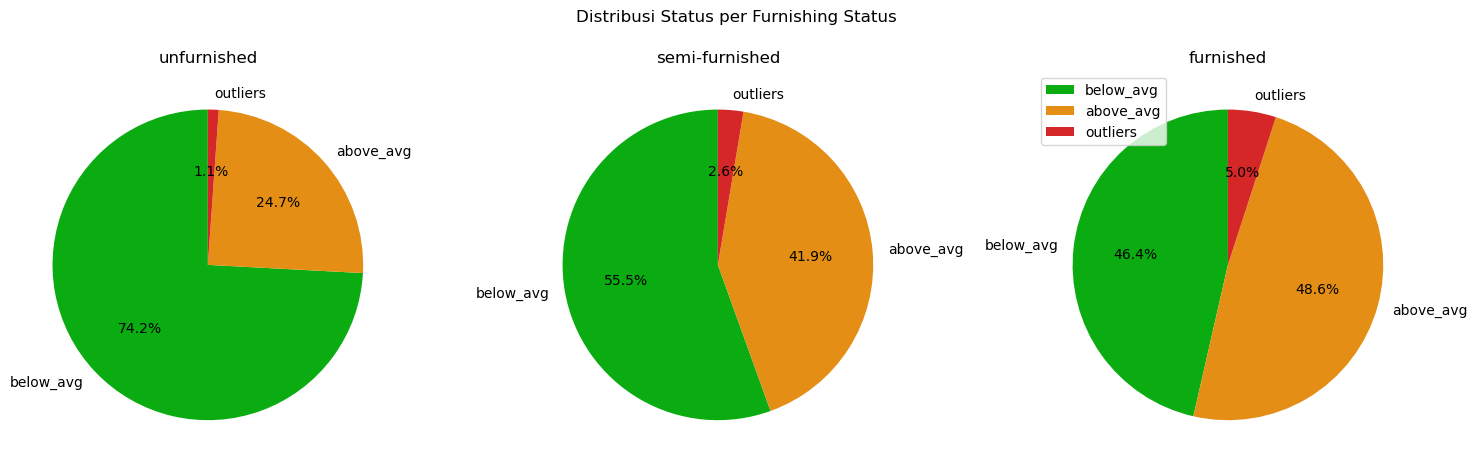

In [12]:
order = ['below_avg', 'above_avg', 'outliers']
furnishing_order = ['unfurnished', 'semi-furnished', 'furnished']  # left → right

ct = pd.crosstab(df['furnishingstatus'], df['status'])
ct = ct.reindex(furnishing_order)  # ← reorder rows

fig, axes = plt.subplots(1, len(ct), figsize=(15, 5))

for i, (idx, row) in enumerate(ct.iterrows()):
    row = row.reindex(order, fill_value=0)

    axes[i].pie(row,
                labels=row.index,
                autopct='%1.1f%%',
                startangle=90,
                colors=["#0bac11", "#e48e15", "#d62728"])

    axes[i].set_title(f'{idx}')

plt.suptitle('Distribusi Status per Furnishing Status')
plt.legend()
plt.tight_layout()
plt.show()

- Proporsi kategori harga above average dan outlier semakin banyak ketika disandingkan mulai dari unfurnished -> semi-furnished -> furnished. artinya furnishstatus juga ada pengaruh terhadap harga rumah.

# Statistik Deskriptif

In [6]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [13]:
print(f"Rata-rata harga rumah: {df['price'].mean()}")
print(f"Median harga rumah: {df['price'].median()}")
print(f"Standar deviasi harga rumah: {np.std(df['price'])}")
print(f"Range harga rumah: {df['price'].max() - df['price'].min()}")
print(f"IQR harga rumah: {df['price'].quantile(0.75) - df['price'].quantile(0.25)}")
print(f"Quantile 1 harga rumah: {df['price'].quantile(0.25)}")
print(f"Quantile 3 harga rumah: {df['price'].quantile(0.75)}")
print()
print(f"Rata-rata luas rumah (sq.ft): {df['area'].mean()}")
print(f"Median luas rumah (sq.ft): {df['area'].median()}")
print(f"Standar deviasi luas rumah (sq.ft): {np.std(df['area'])}")
print(f"Range luas rumah (sq.ft): {df['area'].max() - df['area'].min()}")
print()
print(f"Rata-rata jumlah kamar tidur yang dimiliki tiap rumah: {round(df['bedrooms'].mean())}")
print(f"Median jumlah kamar tidur yang dimiliki tiap rumah: {round(df['bedrooms'].median())}")
print(f"Standar deviasi jumlah kamar tidur yang dimiliki tiap rumah: {round(np.std(df['bedrooms']))}")
print(f"Range jumlah kamar tidur yang dimiliki tiap rumah: {df['bedrooms'].max() - df['bedrooms'].min()}")


Rata-rata harga rumah: 4766729.247706422
Median harga rumah: 4340000.0
Standar deviasi harga rumah: 1868722.8281312098
Range harga rumah: 11550000
IQR harga rumah: 2310000.0
Quantile 1 harga rumah: 3430000.0
Quantile 3 harga rumah: 5740000.0

Rata-rata luas rumah (sq.ft): 5150.54128440367
Median luas rumah (sq.ft): 4600.0
Standar deviasi luas rumah (sq.ft): 2168.1491533213048
Range luas rumah (sq.ft): 14550

Rata-rata jumlah kamar tidur yang dimiliki tiap rumah: 3
Median jumlah kamar tidur yang dimiliki tiap rumah: 3
Standar deviasi jumlah kamar tidur yang dimiliki tiap rumah: 1
Range jumlah kamar tidur yang dimiliki tiap rumah: 5


# Statistik Inferensial

In [ ]:
mean_area = df['area'].mean()
df['area_group'] = df['area'].apply(lambda x: 'Above Avg' if x > mean_area else 'Below Avg')

above = df[df['area_group'] == 'Above Avg']['price']
below = df[df['area_group'] == 'Below Avg']['price']

# Uji normalitas Shapiro-Wilk karena menggunakan two sample
_, p_above = shapiro(above)
_, p_below = shapiro(below)

print(f"Shapiro-Wilk p-value (Above Avg): {p_above:.4f}")
print(f"Shapiro-Wilk p-value (Below Avg): {p_below:.4f}")

alpha = 0.05
both_normal = p_above > alpha and p_below > alpha

# Uji berdasarkan normalitas
if both_normal:
    print("\nKedua grup normal → menggunakan T-Test")
    _, p_value = ttest_ind(above, below, alternative='greater')
    test_name = "T-Test"
else:
    print("\nSalah satu/kedua grup tidak normal → menggunakan Mann-Whitney U")
    _, p_value = mannwhitneyu(above, below, alternative='greater')
    test_name = "Mann-Whitney U"

print(f"\n[{test_name}] P-value: {p_value:.4f}")

if p_value < alpha:
    print("Tolak H0 → Rumah dengan luas di atas rata-rata memang lebih mahal")
else:
    print("Gagal tolak H0 → Tidak cukup bukti")


Shapiro-Wilk p-value (Above Avg): 0.0000
Shapiro-Wilk p-value (Below Avg): 0.0000

Salah satu/kedua grup tidak normal → menggunakan Mann-Whitney U

[Mann-Whitney U] P-value: 0.0000
Tolak H0 → Rumah dengan luas di atas rata-rata memang lebih mahal


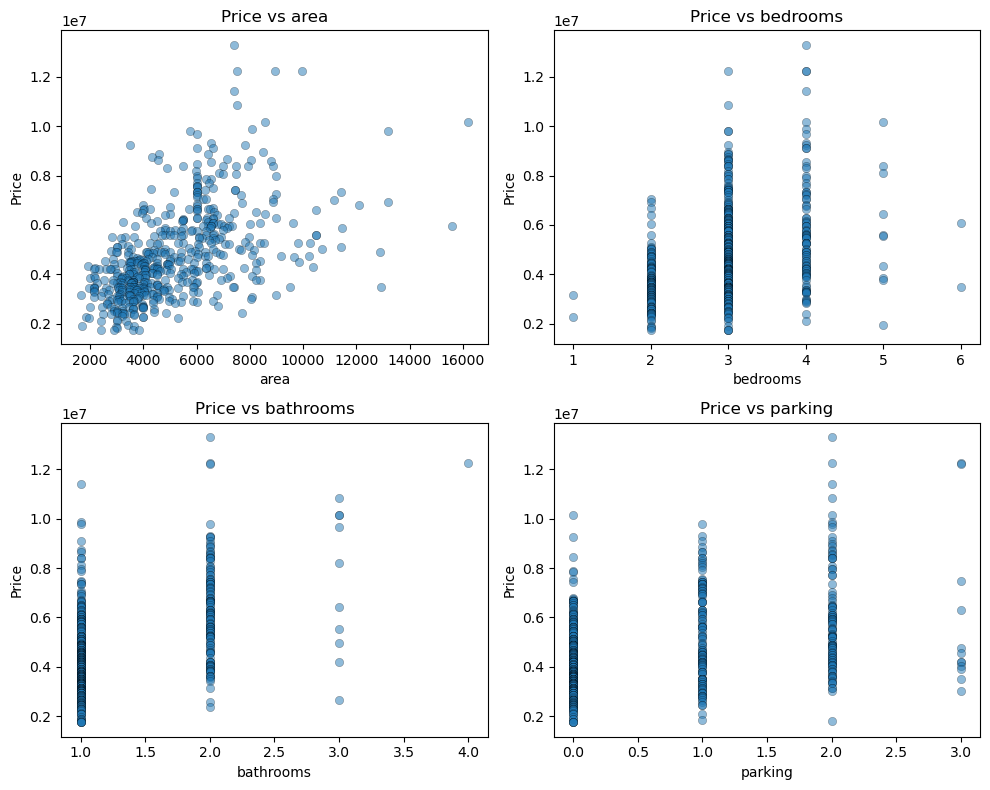

In [20]:
# Ambil semua kolom numerik kecuali 'price' itu sendiri
numeric_cols = df.select_dtypes(include='number').columns.tolist()
numeric_cols = [col for col in numeric_cols if col != 'price']

# Atur layout grid
n_cols = 2
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].scatter(df[col], df['price'], alpha=0.5, edgecolors='k', linewidths=0.3)
    axes[i].set_ylabel('Price')
    axes[i].set_xlabel(col)
    axes[i].set_title(f'Price vs {col}')

# Sembunyikan subplot kosong jika ada
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

- Pada price vs area, dapat dilihat ada korelasi positif antara price dan area
- pada price vs bedroom, distibusi sebaran rumah memiliki jumlah kamar tidur 2,3 atau 4
- pada price vs bathroom, distibusi sebaran rumah memiliki jumlah kamar mandi 1 atau 2
- pada price vs parking, distibusi sebaran rumah memiliki jumlah tempat parkir kurang dari 3


### Chi Square

In [ ]:
def count_chi_square(a, b):
    ct = pd.crosstab(a, b)
    chi2, p, dof, expected = chi2_contingency(ct)
    return chi2, p, dof, expected

In [112]:
chi2, p, dof, expected = count_chi_square(df['mainroad'], df['status'])
print("p-value:", p)

p-value: 3.435872774281718e-08


In [113]:
_, p, _, _ = count_chi_square(df['guestroom'], df['status'])
print("p-value:", p)

p-value: 1.0329029982921647e-12


In [114]:
_, p, _, _ = count_chi_square(df['basement'], df['status'])
print("p-value:", p)

p-value: 4.326177144351489e-06


In [116]:
_, p, _, _ = count_chi_square(df['hotwaterheating'], df['status'])
print("p-value:", p)

p-value: 0.11392678609451211


In [117]:
_, p, _, _ = count_chi_square(df['airconditioning'], df['status'])
print("p-value:", p)

p-value: 8.611685482184198e-21


In [118]:
_, p, _, _ = count_chi_square(df['prefarea'], df['status'])
print("p-value:", p)

p-value: 5.879479865377916e-14


- jika alpha = 0.05, maka variable kategorikal yang punya pvalue < 0.05 atau punya korelasi terhadap harga adalah
- mainroad
- guestroom
- base
- airconditioning
- prefarea


### Spearman

<Axes: >

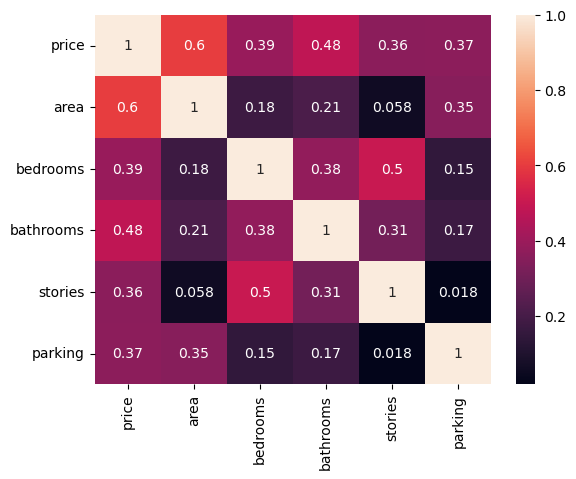

In [ ]:
num_cols = df.select_dtypes(include=['number']).columns
sns.heatmap(df[num_cols].corr(method='spearman'), annot=True) #Menggunakan spearman karena data tidak bertisdribusi normal


- Pada korelasi untuk kolom numerikal, ditemukan semua variable numeri memiliki korelasi positif terhadap harga rumah
- Korelasi yang paling kuat terhadap harga adalah area

# Conclusion

- Harga rumah dibawah rata rata memiliki fasilitas standar seperti rumah pada umumnya
- Harga rumah diatas rata rata memiliki fasilitas sedikit lebih banyak dibandingkan dibawah rata rata
- Harga rumah yang termasuk outlier, merupakan rumah dengan fasilitas++ yang mungkin diperuntukkan rumah keluarga besar